
# Phase 2A v3 — Real ERA5 3-hour Physics-Informed Thermal Forecast (Oklahoma)

## Frozen question
**Can a PINN improve short-horizon prediction of the real atmospheric temperature field during an Oklahoma heat-dome event when future temperature is completely hidden but meteorological forcing is available?**

This v2 notebook fixes the only failure encountered in v1: the auxiliary neural surrogate used to represent the \(t=0\) initial field reached RMSE 0.092 K at one forecast origin and triggered the deliberately conservative 0.08 K stop gate.

**v2 does not loosen that threshold. It removes the approximation altogether.**

The initial ERA5 potential-temperature field is now represented by a **frozen differentiable bilinear interpolator in \(x,y\)** at each pressure level, followed by quadratic interpolation in pressure. Therefore:

- the initial condition is exact (up to floating-point roundoff) at every physically valid ERA5 grid node;
- no auxiliary IC neural network is trained;
- no arbitrary IC-RMSE acceptance threshold is needed;
- the forecast correction is still exactly zero at \(t=0\).

One additional technical correction found during review is included: physics collocation now samples **continuous pressure values from 700–925 hPa**, rather than only the three observed pressure levels. ERA5 forcing is interpolated continuously in pressure at those unlabeled collocation points.

Phase 1 remains closed: the repaired spatial-reconstruction PINN had mean RMSE about **0.3690 K** versus **0.3647 K** for the matched data-only network.

## Phase 2A task

- past 12 h of real ERA5 temperature are available;
- the real atmospheric state at forecast origin \(t=0\) is available;
- future temperature at +1, +2, +3 h is never used in optimization;
- future ERA5 \(u,v,\omega,q\) are treated as known meteorological forcing, so this is a **conditional retrospective forecast/hindcast**;
- the network predicts potential temperature \(\theta\), then converts it to ordinary temperature \(T\) for scoring;
- physics is enforced at unlabeled future collocation points;
- baselines are persistence, local linear trend, a matched coordinate-only NN, and a forcing-aware NN.

## Governing equation

\[
\theta_t+u\theta_x+v\theta_y+\omega\theta_p=Q_\theta.
\]

The unresolved heating is deliberately low-dimensional:

\[
Q_\theta=
\alpha_L Q_{\mathrm{latent}}
+b_0+b_p p^*
+b_s\sin(2\pi t/24)
+b_c\cos(2\pi t/24).
\]

Those closure coefficients are learned **only from the past/training stage**, then frozen before future causal training.

### Reliability protections

- explicit physical-unit conversions;
- potential-temperature round-trip test;
- manufactured-solution test of the PDE residual;
- surface-pressure terrain screening;
- 4° horizontal buffer around the Oklahoma evaluation domain;
- **exact differentiable initial ERA5 field at valid grid nodes**;
- anchored forecast correction equal to zero at \(t=0\);
- chronological data separation;
- future physics pools contain no future temperature targets;
- causal 1 h → 2 h → 3 h physics training;
- continuous pressure collocation;
- multiple forecast origins and seeds;
- predeclared practical success gate.

A positive result would support a short-horizon thermal-state component for a DigiCARES-style climate-energy digital twin. It would **not** yet establish an operational heat-wave forecasting system.


### v3 runtime repair

The v2 notebook had a concrete coding defect: when the auxiliary initial-condition network was removed, the helper function `make_mlp(...)` was accidentally removed with it even though the forecast models still called it. That makes v2 fail at model construction.

v3 restores that helper and was subjected to an **executed end-to-end synthetic smoke test** covering:
- exact initial-field construction,
- coordinate-only baseline training,
- forcing-aware baseline training,
- PINN Stage A,
- causal +1/+2 h physics stages in the reduced smoke configuration,
- future-physics residual evaluation,
- future evaluation-bundle construction.

That executed smoke test passed before this file was released.


In [1]:
!pip install -q "cdsapi>=0.7.7" xarray netCDF4 h5netcdf scipy pandas matplotlib torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.2 MB/s eta 0:00:00


In [2]:

import copy
import math
import os
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import distance_transform_edt

import torch
import torch.nn as nn
from IPython.display import display

torch.set_default_dtype(torch.float32)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda



## CDS credential
This notebook deliberately does not copy a credential from an earlier notebook.


In [3]:

CDS_KEY = os.environ.get("CDSAPI_KEY", "").strip()
if not CDS_KEY:
    CDS_KEY = "PASTE_YOUR_CDS_KEY_HERE"

if CDS_KEY == "PASTE_YOUR_CDS_KEY_HERE":
    raise ValueError(
        "Paste your CDS API key into CDS_KEY (or set environment variable CDSAPI_KEY), then rerun."
    )

with open(os.path.expanduser("~/.cdsapirc"), "w") as f:
    f.write("url: https://cds.climate.copernicus.eu/api\n")
    f.write(f"key: {CDS_KEY}\n")

print("CDS credential configured.")


CDS credential configured.



## Frozen Phase-2A configuration
Leave `RUN_MODE="gate"` for the scientific run. `"smoke"` is only a runtime/debug check and must not be interpreted scientifically.


In [4]:

EVENT_START = "2026-08-14"
EVENT_END   = "2026-08-17"

# Inner evaluation domain from the Oklahoma audit.
EVAL_LAT_BOUNDS = (33.5, 37.0)
EVAL_LON_BOUNDS = (-100.0, -94.5)

# Large outer buffer. Future T is scored only in the inner domain.
BUFFER_DEG = 4.0
MODEL_LAT_BOUNDS = (EVAL_LAT_BOUNDS[0] - BUFFER_DEG, EVAL_LAT_BOUNDS[1] + BUFFER_DEG)
MODEL_LON_BOUNDS = (EVAL_LON_BOUNDS[0] - BUFFER_DEG, EVAL_LON_BOUNDS[1] + BUFFER_DEG)

PRESSURE_LEVELS_HPA = np.array([700.0, 850.0, 925.0])
P0_HPA = 1000.0

HISTORY_HOURS = 12
FORECAST_HOURS = 3
TREND_HOURS = 4

FORECAST_ORIGINS_GATE = [
    "2026-08-15 12:00:00",
    "2026-08-15 18:00:00",
    "2026-08-16 12:00:00",
    "2026-08-16 18:00:00",
]
SEEDS_GATE = [101, 202]

RUN_MODE = "gate"  # "gate" or "smoke"
if RUN_MODE == "smoke":
    FORECAST_ORIGINS = FORECAST_ORIGINS_GATE[:1]
    SEEDS = [101]
else:
    FORECAST_ORIGINS = FORECAST_ORIGINS_GATE
    SEEDS = SEEDS_GATE

SURFACE_PRESSURE_MARGIN_HPA = 20.0

HIDDEN = 64
LAYERS = 4

# Exact differentiable initial-field check.
EXACT_IC_GRID_RMSE_TOL_K = 2e-4

# Main models.
STAGE_A_STEPS = 1500
FUTURE_STAGE_STEPS = 1000
TOTAL_MAIN_STEPS = STAGE_A_STEPS + FORECAST_HOURS * FUTURE_STAGE_STEPS

DATA_BATCH = 4096
PHYS_BATCH = 2048
BOUNDARY_BATCH = 768

PAST_PHYS_POOL = 50000
FUTURE_PHYS_POOL = 50000
BOUNDARY_POOL = 15000

LEARNING_RATE = 1e-3
GRAD_CLIP = 5.0

LAMBDA_PHYSICS = 1.0
LAMBDA_BOUNDARY = 0.05
LAMBDA_SOURCE_REG = 1e-3

MAX_LATENT_SCALE = 2.0
MAX_B0_K_PER_H = 0.30
MAX_BP_K_PER_H = 0.30
MAX_DIURNAL_K_PER_H = 0.50

# Practical screening gate, not a formal statistical test.
MIN_MEAN_IMPROVEMENT_PCT = 5.0
MIN_WIN_RATE = 0.67
MIN_LEAD3_WIN_RATE = 0.50

ERA5_FILE = "era5_phase2A_oklahoma_pressure.nc"
SURFACE_FILE = "era5_phase2A_oklahoma_surface.nc"

print("Run mode:", RUN_MODE)
print("Origins:", FORECAST_ORIGINS)
print("Seeds:", SEEDS)
print("Evaluation region:", EVAL_LAT_BOUNDS, EVAL_LON_BOUNDS)
print("Buffered model region:", MODEL_LAT_BOUNDS, MODEL_LON_BOUNDS)


Run mode: gate
Origins: ['2026-08-15 12:00:00', '2026-08-15 18:00:00', '2026-08-16 12:00:00', '2026-08-16 18:00:00']
Seeds: [101, 202]
Evaluation region: (33.5, 37.0) (-100.0, -94.5)
Buffered model region: (29.5, 41.0) (-104.0, -90.5)



## Download ERA5
ERA5 pressure-level fields used here are temperature, horizontal wind, pressure vertical velocity, and specific humidity. Surface pressure is downloaded separately for terrain screening.


In [5]:

import cdsapi

days = pd.date_range(EVENT_START, EVENT_END, freq="D")
if days.to_period("M").nunique() != 1:
    raise ValueError("The requested event must stay within one calendar month.")

area = [
    MODEL_LAT_BOUNDS[1],
    MODEL_LON_BOUNDS[0],
    MODEL_LAT_BOUNDS[0],
    MODEL_LON_BOUNDS[1],
]
hours_req = [f"{h:02d}:00" for h in range(24)]

pressure_request = {
    "product_type": ["reanalysis"],
    "variable": [
        "temperature",
        "u_component_of_wind",
        "v_component_of_wind",
        "vertical_velocity",
        "specific_humidity",
    ],
    "pressure_level": [str(int(p)) for p in PRESSURE_LEVELS_HPA],
    "year": [days[0].strftime("%Y")],
    "month": [days[0].strftime("%m")],
    "day": [d.strftime("%d") for d in days],
    "time": hours_req,
    "area": area,
    "data_format": "netcdf",
    "download_format": "unarchived",
}

surface_request = {
    "product_type": ["reanalysis"],
    "variable": ["surface_pressure"],
    "year": [days[0].strftime("%Y")],
    "month": [days[0].strftime("%m")],
    "day": [d.strftime("%d") for d in days],
    "time": hours_req,
    "area": area,
    "data_format": "netcdf",
    "download_format": "unarchived",
}

client = cdsapi.Client()

if not Path(ERA5_FILE).exists():
    client.retrieve("reanalysis-era5-pressure-levels", pressure_request, ERA5_FILE)
    print("Saved:", ERA5_FILE)
else:
    print("Using existing:", ERA5_FILE)

if not Path(SURFACE_FILE).exists():
    client.retrieve("reanalysis-era5-single-levels", surface_request, SURFACE_FILE)
    print("Saved:", SURFACE_FILE)
else:
    print("Using existing:", SURFACE_FILE)


2026-09-11 18:06:10,553 INFO Request ID is 10c9ef93-2db6-4044-b9bb-4a006097be6f
INFO:ecmwf.datastores.legacy_client:Request ID is 10c9ef93-2db6-4044-b9bb-4a006097be6f
2026-09-11 18:06:10,760 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-09-11 18:06:30,250 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-09-11 18:06:38,049 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


3b07ad0649737c209e72c1aa07a5333e.nc:   0%|          | 0.00/7.45M [00:00<?, ?B/s]

Saved: era5_phase2A_oklahoma_pressure.nc


2026-09-11 18:06:41,885 INFO Request ID is 92380670-da65-4df0-9bcb-77362a789b7c
INFO:ecmwf.datastores.legacy_client:Request ID is 92380670-da65-4df0-9bcb-77362a789b7c
2026-09-11 18:06:42,076 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-09-11 18:07:05,998 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-09-11 18:07:17,593 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


d9f580b2472eef470a9a6531f0e5cdc.nc:   0%|          | 0.00/393k [00:00<?, ?B/s]

Saved: era5_phase2A_oklahoma_surface.nc


## Load and standardize arrays

In [6]:

def find_name(options, available, kind):
    for name in options:
        if name in available:
            return name
    raise KeyError(f"Could not find {kind}. Available: {list(available)}")

ds = xr.open_dataset(ERA5_FILE)

time_name = find_name(["valid_time", "time"], ds.coords, "time")
level_name = find_name(["pressure_level", "level"], ds.coords, "pressure")
lat_name = find_name(["latitude", "lat"], ds.coords, "latitude")
lon_name = find_name(["longitude", "lon"], ds.coords, "longitude")

T_name = find_name(["t", "temperature"], ds.data_vars, "temperature")
U_name = find_name(["u", "u_component_of_wind"], ds.data_vars, "u wind")
V_name = find_name(["v", "v_component_of_wind"], ds.data_vars, "v wind")
W_name = find_name(["w", "vertical_velocity"], ds.data_vars, "vertical velocity")
Q_name = find_name(["q", "specific_humidity"], ds.data_vars, "specific humidity")

ds = ds.sortby(time_name).sortby(level_name).sortby(lat_name).sortby(lon_name)

times = pd.to_datetime(ds[time_name].values)
levels = ds[level_name].values.astype(float)
lats = ds[lat_name].values.astype(float)
lons = ds[lon_name].values.astype(float)

if not np.allclose(levels, PRESSURE_LEVELS_HPA):
    raise ValueError(f"Expected pressure levels {PRESSURE_LEVELS_HPA}; found {levels}")

hours_from_start = np.asarray(
    (times - times[0]) / np.timedelta64(1, "h"),
    dtype=float,
)

def arr4(name):
    return ds[name].transpose(time_name, level_name, lat_name, lon_name).values.astype(np.float64)

T_K = arr4(T_name)
U_MS = arr4(U_name)
V_MS = arr4(V_name)
OMEGA_PA_S = arr4(W_name)
Q_SPEC = arr4(Q_name)

ds_sp = xr.open_dataset(SURFACE_FILE)
sp_time = find_name(["valid_time", "time"], ds_sp.coords, "surface time")
sp_lat = find_name(["latitude", "lat"], ds_sp.coords, "surface latitude")
sp_lon = find_name(["longitude", "lon"], ds_sp.coords, "surface longitude")
sp_name = find_name(["sp", "surface_pressure"], ds_sp.data_vars, "surface pressure")

ds_sp = ds_sp.sortby(sp_time).sortby(sp_lat).sortby(sp_lon)
SP_PA = ds_sp[sp_name].transpose(sp_time, sp_lat, sp_lon).values.astype(np.float64)

if SP_PA.shape != (len(times), len(lats), len(lons)):
    raise ValueError("Surface-pressure grid is not aligned with pressure-level grid.")

if not np.allclose(np.diff(hours_from_start), 1.0):
    raise ValueError("Expected exactly hourly ERA5 samples.")

print("Shape [time,p,lat,lon]:", T_K.shape)
print("Times:", times[0], "to", times[-1])
print("Levels:", levels)
print("Lat:", lats[0], "to", lats[-1])
print("Lon:", lons[0], "to", lons[-1])


Shape [time,p,lat,lon]: (96, 3, 47, 55)
Times: 2026-08-14 00:00:00 to 2026-08-17 23:00:00
Levels: [700. 850. 925.]
Lat: 29.5 to 41.0
Lon: -104.0 to -90.5



## Potential temperature and physical units

\[
\theta=T\left(\frac{1000}{p}\right)^{R_d/c_p}.
\]

The PDE is evaluated in:
- hours,
- km,
- hPa,
- K.

ERA5 \(\omega\) is in Pa/s, so \(1\ {\rm Pa/s}=36\ {\rm hPa/h}\).


In [7]:

R_D = 287.05
C_P = 1004.0
L_V = 2.5e6
KAPPA = R_D / C_P

lat0 = 0.5 * (MODEL_LAT_BOUNDS[0] + MODEL_LAT_BOUNDS[1])
KM_PER_DEG_LAT = 111.0
KM_PER_DEG_LON = 111.0 * np.cos(np.radians(lat0))

x_km = (lons - np.mean(MODEL_LON_BOUNDS)) * KM_PER_DEG_LON
y_km = (lats - lat0) * KM_PER_DEG_LAT

exner_inverse = (P0_HPA / levels) ** KAPPA
THETA_K = T_K * exner_inverse[None, :, None, None]

U_KM_H = U_MS * 3.6
V_KM_H = V_MS * 3.6
OMEGA_HPA_H = OMEGA_PA_S * 36.0

T_roundtrip = THETA_K / exner_inverse[None, :, None, None]
roundtrip_err = float(np.nanmax(np.abs(T_roundtrip - T_K)))
assert roundtrip_err < 1e-10
assert np.isclose(36.0, 1.0 * 3600.0 / 100.0)

print("Potential-temperature round-trip max error:", roundtrip_err)
print("Omega conversion check: 1 Pa/s = 36 hPa/h")


Potential-temperature round-trip max error: 0.0
Omega conversion check: 1 Pa/s = 36 hPa/h



## Humidity-derived latent-heating proxy

\[
\frac{Dq}{Dt}=q_t+u q_x+v q_y+\omega q_p.
\]

Then
\[
Q_{\rm latent,T}= -\frac{L_v}{c_p}\frac{Dq}{Dt},
\]
and it is converted to potential-temperature tendency by \((1000/p)^\kappa\).


In [8]:

Q_t = np.gradient(Q_SPEC, hours_from_start, axis=0, edge_order=2)
Q_p = np.gradient(Q_SPEC, levels, axis=1, edge_order=2)
Q_y = np.gradient(Q_SPEC, y_km, axis=2, edge_order=2)
Q_x = np.gradient(Q_SPEC, x_km, axis=3, edge_order=2)

DqDt = Q_t + U_KM_H * Q_x + V_KM_H * Q_y + OMEGA_HPA_H * Q_p
LATENT_T_K_H = -(L_V / C_P) * DqDt
LATENT_THETA_K_H = LATENT_T_K_H * exner_inverse[None, :, None, None]

print("Latent proxy finite fraction:", np.isfinite(LATENT_THETA_K_H).mean())
print("Latent proxy [1,50,99] percentiles K/h:",
      np.nanpercentile(LATENT_THETA_K_H, [1, 50, 99]))


Latent proxy finite fraction: 1.0
Latent proxy [1,50,99] percentiles K/h: [-4.50837376 -0.01414593  3.67135751]


## Forcing interpolators — no temperature target is included

In [9]:

def interp4(field):
    return RegularGridInterpolator(
        (hours_from_start, levels, y_km, x_km),
        field,
        bounds_error=False,
        fill_value=np.nan,
    )

U_interp = interp4(U_KM_H)
V_interp = interp4(V_KM_H)
W_interp = interp4(OMEGA_HPA_H)
LAT_interp = interp4(LATENT_THETA_K_H)

SP_interp = RegularGridInterpolator(
    (hours_from_start, y_km, x_km),
    SP_PA / 100.0,
    bounds_error=False,
    fill_value=np.nan,
)

print("Forcing interpolators ready.")


Forcing interpolators ready.


## Data preparation and leakage guards

In [10]:

def time_index_exact(timestamp):
    ts = pd.Timestamp(timestamp)
    hits = np.where(times == ts)[0]
    if len(hits) != 1:
        raise ValueError(f"Forecast origin {ts} is not exactly present.")
    return int(hits[0])

def valid_pressure_mask(time_idx, p_hpa):
    return (SP_PA[time_idx] / 100.0) >= (float(p_hpa) + SURFACE_PRESSURE_MARGIN_HPA)

lon2, lat2 = np.meshgrid(lons, lats)
INNER_XY = (
    (lat2 >= EVAL_LAT_BOUNDS[0])
    & (lat2 <= EVAL_LAT_BOUNDS[1])
    & (lon2 >= EVAL_LON_BOUNDS[0])
    & (lon2 <= EVAL_LON_BOUNDS[1])
)

def utc_phase_from_abs_hour(abs_hour):
    base_hour = times[0].hour + times[0].minute/60.0 + times[0].second/3600.0
    hour_of_day = np.mod(base_hour + np.asarray(abs_hour), 24.0)
    angle = 2.0 * np.pi * hour_of_day / 24.0
    return np.sin(angle), np.cos(angle)

@dataclass
class OriginBundle:
    origin: pd.Timestamp
    origin_idx: int
    train_coords: np.ndarray
    train_theta: np.ndarray
    train_meta: np.ndarray
    train_forcing_extra: np.ndarray
    ic_xy: np.ndarray
    ic_theta_levels: np.ndarray
    ic_valid_levels: np.ndarray
    data_scale: float
    tendency_scale: float
    forcing_mean: np.ndarray
    forcing_std: np.ndarray
    past_phys: dict
    future_phys: dict
    future_boundary: dict

def build_grid_rows(time_indices, origin_idx, inner_only=False):
    coords_list, theta_list, meta_list, extra_list = [], [], [], []
    xy_selector = INNER_XY if inner_only else np.ones((len(lats), len(lons)), dtype=bool)

    for it in time_indices:
        tau = float(hours_from_start[it] - hours_from_start[origin_idx])
        s_t, c_t = utc_phase_from_abs_hour(hours_from_start[it])

        for ip, p in enumerate(levels):
            # Fixed domain: a point must be physically above ground both at current time and t0.
            valid = (
                valid_pressure_mask(it, p)
                & valid_pressure_mask(origin_idx, p)
                & xy_selector
            )
            iy, ix = np.where(valid)
            if len(iy) == 0:
                continue

            n = len(iy)
            coords = np.column_stack([
                x_km[ix],
                y_km[iy],
                np.full(n, p),
                np.full(n, tau),
            ])
            theta = THETA_K[it, ip, iy, ix]
            meta = np.column_stack([
                np.full(n, it, dtype=int),
                np.full(n, ip, dtype=int),
                iy.astype(int),
                ix.astype(int),
            ])
            extra = np.column_stack([
                U_KM_H[it, ip, iy, ix],
                V_KM_H[it, ip, iy, ix],
                OMEGA_HPA_H[it, ip, iy, ix],
                Q_SPEC[it, ip, iy, ix],
                LATENT_THETA_K_H[it, ip, iy, ix],
                np.full(n, s_t),
                np.full(n, c_t),
            ])

            coords_list.append(coords)
            theta_list.append(theta)
            meta_list.append(meta)
            extra_list.append(extra)

    return (
        np.concatenate(coords_list),
        np.concatenate(theta_list),
        np.concatenate(meta_list),
        np.concatenate(extra_list),
    )

def make_ic_arrays(origin_idx):
    x2, y2 = np.meshgrid(x_km, y_km)
    ic_xy = np.column_stack([x2.ravel(), y2.ravel()])
    targets = np.column_stack([THETA_K[origin_idx, ip].ravel() for ip in range(len(levels))])
    valid = np.column_stack([valid_pressure_mask(origin_idx, p).ravel() for p in levels])
    return ic_xy, targets, valid

def sample_collocation_pool(origin_idx, tau_low, tau_high, n_target, boundary=False, seed=0):
    rng = np.random.default_rng(seed)
    chunks = {k: [] for k in ["coords", "u", "v", "w", "latent", "sin", "cos"]}

    def current_n():
        return sum(len(a) for a in chunks["u"])

    attempts = 0
    while current_n() < n_target:
        attempts += 1
        if attempts > 100:
            raise RuntimeError("Unable to generate enough valid collocation points.")

        m = max(4096, n_target // 2)
        tau = rng.uniform(tau_low, tau_high, size=m)
        p = rng.uniform(float(levels[0]), float(levels[-1]), size=m)

        if boundary:
            side = rng.integers(0, 4, size=m)
            x = rng.uniform(x_km[0], x_km[-1], size=m)
            y = rng.uniform(y_km[0], y_km[-1], size=m)
            x[side == 0] = x_km[0]
            x[side == 1] = x_km[-1]
            y[side == 2] = y_km[0]
            y[side == 3] = y_km[-1]
        else:
            x = rng.uniform(x_km[0], x_km[-1], size=m)
            y = rng.uniform(y_km[0], y_km[-1], size=m)

        abs_hour = hours_from_start[origin_idx] + tau
        pts4 = np.column_stack([abs_hour, p, y, x])
        pts3 = np.column_stack([abs_hour, y, x])
        pts3_0 = np.column_stack([
            np.full(m, hours_from_start[origin_idx]), y, x
        ])

        sp_now = SP_interp(pts3)
        sp_0 = SP_interp(pts3_0)

        valid = (
            np.isfinite(sp_now)
            & np.isfinite(sp_0)
            & (sp_now >= p + SURFACE_PRESSURE_MARGIN_HPA)
            & (sp_0 >= p + SURFACE_PRESSURE_MARGIN_HPA)
        )
        if not valid.any():
            continue

        pts4_v = pts4[valid]
        u = U_interp(pts4_v)
        v = V_interp(pts4_v)
        w = W_interp(pts4_v)
        latent = LAT_interp(pts4_v)

        fv = np.isfinite(u) & np.isfinite(v) & np.isfinite(w) & np.isfinite(latent)
        if not fv.any():
            continue

        idx = np.where(valid)[0][fv]
        coords = np.column_stack([x[idx], y[idx], p[idx], tau[idx]])
        s_t, c_t = utc_phase_from_abs_hour(abs_hour[idx])

        chunks["coords"].append(coords)
        chunks["u"].append(u[fv])
        chunks["v"].append(v[fv])
        chunks["w"].append(w[fv])
        chunks["latent"].append(latent[fv])
        chunks["sin"].append(s_t)
        chunks["cos"].append(c_t)

    result = {k: np.concatenate(v, axis=0)[:n_target] for k, v in chunks.items()}

    # Explicit leakage guard: future physics pool contains forcing only.
    forbidden = {"theta", "temperature", "target", "truth", "T"}
    assert forbidden.isdisjoint(result.keys())
    return result

def prepare_origin(origin, pool_seed=12345):
    oi = time_index_exact(origin)

    if oi - HISTORY_HOURS < 0:
        raise ValueError("Insufficient 12-h history.")
    if oi + FORECAST_HOURS >= len(times):
        raise ValueError("Insufficient future hours.")

    past_indices = list(range(oi - HISTORY_HOURS, oi))  # excludes t=0
    train_coords, train_theta, train_meta, train_extra = build_grid_rows(
        past_indices, oi, inner_only=False
    )

    assert np.max(train_coords[:, 3]) < 0.0
    assert np.min(train_coords[:, 3]) >= -HISTORY_HOURS

    ic_xy, ic_theta_levels, ic_valid_levels = make_ic_arrays(oi)

    ip = train_meta[:, 1].astype(int)
    iy = train_meta[:, 2].astype(int)
    ix = train_meta[:, 3].astype(int)
    theta0_ref = THETA_K[oi, ip, iy, ix]
    data_scale = max(float(np.std(train_theta - theta0_ref)), 0.5)

    # Past-only tendency scale: differences end at t=0 and never use future T.
    hist_plus_ic = THETA_K[oi-HISTORY_HOURS:oi+1]
    tendency_scale = max(float(np.nanstd(np.diff(hist_plus_ic, axis=0))), 0.10)

    forcing_mean = np.nanmean(train_extra, axis=0)
    forcing_std = np.nanstd(train_extra, axis=0)
    forcing_std = np.where(forcing_std < 1e-8, 1.0, forcing_std)

    past_phys = sample_collocation_pool(
        oi, -HISTORY_HOURS, 0.0, PAST_PHYS_POOL,
        boundary=False, seed=pool_seed + oi
    )
    future_phys = sample_collocation_pool(
        oi, 0.0, FORECAST_HOURS, FUTURE_PHYS_POOL,
        boundary=False, seed=pool_seed + 1000 + oi
    )
    future_boundary = sample_collocation_pool(
        oi, 0.0, FORECAST_HOURS, BOUNDARY_POOL,
        boundary=True, seed=pool_seed + 2000 + oi
    )

    return OriginBundle(
        origin=pd.Timestamp(origin),
        origin_idx=oi,
        train_coords=train_coords,
        train_theta=train_theta,
        train_meta=train_meta,
        train_forcing_extra=train_extra,
        ic_xy=ic_xy,
        ic_theta_levels=ic_theta_levels,
        ic_valid_levels=ic_valid_levels,
        data_scale=data_scale,
        tendency_scale=tendency_scale,
        forcing_mean=forcing_mean,
        forcing_std=forcing_std,
        past_phys=past_phys,
        future_phys=future_phys,
        future_boundary=future_boundary,
    )

print("Data preparation helpers ready.")


Data preparation helpers ready.



## Exact differentiable initial field

v1 used a small 2D neural network to approximate the ERA5 field at \(t=0\). That auxiliary approximation was unnecessary and caused the run to stop at origin 2 when its RMSE reached 0.092 K.

v2 instead uses the actual ERA5 \(t=0\) field:

1. at each pressure level, terrain-invalid grid nodes are filled **only for interpolation support** using the nearest physically valid node;
2. a frozen bilinear interpolator evaluates the field continuously in \(x,y\);
3. the three level values are combined continuously in pressure by the same quadratic Lagrange interpolation used by the forecast model.

At every physically valid ERA5 grid node, the initial field must reproduce ERA5 to floating-point accuracy. The notebook aborts if this exact-grid test fails.

The interpolator is piecewise differentiable, which is sufficient for the first-order Phase-2A PDE residual.


In [11]:

def nearest_valid_fill(arr2d, valid2d):
    arr2d = np.asarray(arr2d, dtype=np.float64)
    valid2d = np.asarray(valid2d, dtype=bool)

    if valid2d.all():
        return arr2d.copy()
    if not valid2d.any():
        raise RuntimeError("A pressure level has no physically valid t=0 grid nodes.")

    inds = distance_transform_edt(
        ~valid2d,
        return_distances=False,
        return_indices=True,
    )
    return arr2d[tuple(inds)]


class ExactInitialField(nn.Module):
    # Frozen piecewise-bilinear x/y interpolation of t=0 theta at 3 pressure levels.
    def __init__(self, level_grids):
        super().__init__()
        self.register_buffer(
            "x_axis",
            torch.tensor(x_km, dtype=torch.float32),
        )
        self.register_buffer(
            "y_axis",
            torch.tensor(y_km, dtype=torch.float32),
        )
        self.register_buffer(
            "grids",
            torch.tensor(level_grids, dtype=torch.float32),
        )

    def forward(self, xy):
        xq = torch.clamp(xy[:, 0], self.x_axis[0], self.x_axis[-1])
        yq = torch.clamp(xy[:, 1], self.y_axis[0], self.y_axis[-1])

        ix = torch.searchsorted(self.x_axis, xq, right=True) - 1
        iy = torch.searchsorted(self.y_axis, yq, right=True) - 1

        ix = torch.clamp(ix, 0, len(self.x_axis) - 2)
        iy = torch.clamp(iy, 0, len(self.y_axis) - 2)

        x0 = self.x_axis[ix]
        x1 = self.x_axis[ix + 1]
        y0 = self.y_axis[iy]
        y1 = self.y_axis[iy + 1]

        wx = ((xq - x0) / (x1 - x0)).unsqueeze(1)
        wy = ((yq - y0) / (y1 - y0)).unsqueeze(1)

        f00 = self.grids[:, iy,     ix    ].T
        f10 = self.grids[:, iy,     ix + 1].T
        f01 = self.grids[:, iy + 1, ix    ].T
        f11 = self.grids[:, iy + 1, ix + 1].T

        return (
            (1.0 - wx) * (1.0 - wy) * f00
            + wx * (1.0 - wy) * f10
            + (1.0 - wx) * wy * f01
            + wx * wy * f11
        )


def build_exact_initial_field(bundle):
    ny, nx = len(lats), len(lons)

    filled_levels = []
    for j, p in enumerate(levels):
        grid = bundle.ic_theta_levels[:, j].reshape(ny, nx)
        valid = bundle.ic_valid_levels[:, j].reshape(ny, nx)
        filled_levels.append(nearest_valid_fill(grid, valid))

    level_grids = np.stack(filled_levels, axis=0)
    model = ExactInitialField(level_grids).to(device)
    model.eval()

    xy_t = torch.tensor(bundle.ic_xy, dtype=torch.float32, device=device)
    with torch.no_grad():
        pred = model(xy_t).cpu().numpy()

    valid = bundle.ic_valid_levels.astype(bool)
    truth = bundle.ic_theta_levels

    err = pred[valid] - truth[valid]
    overall_rmse = float(np.sqrt(np.mean(err**2)))

    per_level = {}
    for j, p in enumerate(levels):
        e = pred[valid[:, j], j] - truth[valid[:, j], j]
        per_level[float(p)] = float(np.sqrt(np.mean(e**2)))

    print(f"    Exact IC grid RMSE={overall_rmse:.8f} K")
    print("    Exact IC per-level RMSE:", per_level)

    if overall_rmse > EXACT_IC_GRID_RMSE_TOL_K:
        raise RuntimeError(
            f"Exact initial-field interpolation check failed: "
            f"{overall_rmse:.8f} K > {EXACT_IC_GRID_RMSE_TOL_K:.8f} K."
        )

    for par in model.parameters():
        par.requires_grad_(False)

    return model, overall_rmse, per_level


## Anchored forecast models

In [12]:
def make_mlp(in_dim, out_dim, hidden, layers):
    modules = [nn.Linear(in_dim, hidden), nn.Tanh()]
    for _ in range(layers - 1):
        modules += [nn.Linear(hidden, hidden), nn.Tanh()]
    modules += [nn.Linear(hidden, out_dim)]
    return nn.Sequential(*modules)


def lagrange_weights(p):
    p0, p1, p2 = [float(v) for v in levels]
    L0 = (p-p1)*(p-p2)/((p0-p1)*(p0-p2))
    L1 = (p-p0)*(p-p2)/((p1-p0)*(p1-p2))
    L2 = (p-p0)*(p-p1)/((p2-p0)*(p2-p1))
    return torch.stack([L0,L1,L2], dim=1)

class AnchoredCoordinateModel(nn.Module):
    def __init__(self, ic_model, delta_scale):
        super().__init__()
        self.ic_model = ic_model
        self.delta_scale = float(delta_scale)
        self.xmin, self.xmax = float(x_km[0]), float(x_km[-1])
        self.ymin, self.ymax = float(y_km[0]), float(y_km[-1])
        self.pmin, self.pmax = float(levels[0]), float(levels[-1])
        self.net = make_mlp(4, 1, HIDDEN, LAYERS)

    def initial_theta(self, coords):
        vals = self.ic_model(coords[:,:2])
        return torch.sum(vals * lagrange_weights(coords[:,2]), dim=1)

    def norm_coords(self, coords):
        x = 2.0*(coords[:,0]-self.xmin)/(self.xmax-self.xmin)-1.0
        y = 2.0*(coords[:,1]-self.ymin)/(self.ymax-self.ymin)-1.0
        p = 2.0*(coords[:,2]-self.pmin)/(self.pmax-self.pmin)-1.0
        tau = coords[:,3] / HISTORY_HOURS
        return torch.stack([x,y,p,tau], dim=1)

    def forward(self, coords):
        base = self.initial_theta(coords)
        corr = self.net(self.norm_coords(coords)).squeeze(1)
        return base + (coords[:,3]/HISTORY_HOURS) * self.delta_scale * corr

class AnchoredForcingModel(nn.Module):
    def __init__(self, ic_model, delta_scale, forcing_mean, forcing_std):
        super().__init__()
        self.ic_model = ic_model
        self.delta_scale = float(delta_scale)
        self.xmin, self.xmax = float(x_km[0]), float(x_km[-1])
        self.ymin, self.ymax = float(y_km[0]), float(y_km[-1])
        self.pmin, self.pmax = float(levels[0]), float(levels[-1])
        self.register_buffer("fmean", torch.tensor(forcing_mean, dtype=torch.float32))
        self.register_buffer("fstd", torch.tensor(forcing_std, dtype=torch.float32))
        self.net = make_mlp(4+len(forcing_mean), 1, HIDDEN, LAYERS)

    def initial_theta(self, coords):
        vals = self.ic_model(coords[:,:2])
        return torch.sum(vals * lagrange_weights(coords[:,2]), dim=1)

    def norm_coords(self, coords):
        x = 2.0*(coords[:,0]-self.xmin)/(self.xmax-self.xmin)-1.0
        y = 2.0*(coords[:,1]-self.ymin)/(self.ymax-self.ymin)-1.0
        p = 2.0*(coords[:,2]-self.pmin)/(self.pmax-self.pmin)-1.0
        tau = coords[:,3] / HISTORY_HOURS
        return torch.stack([x,y,p,tau], dim=1)

    def forward(self, coords, extra):
        base = self.initial_theta(coords)
        z = torch.cat(
            [self.norm_coords(coords), (extra-self.fmean)/self.fstd],
            dim=1
        )
        corr = self.net(z).squeeze(1)
        return base + (coords[:,3]/HISTORY_HOURS) * self.delta_scale * corr

print("Anchored models ready.")


Anchored models ready.


## Heating closure and PINN residual

In [13]:

class HeatingClosure(nn.Module):
    def __init__(self):
        super().__init__()
        self.raw_latent = nn.Parameter(torch.tensor(0.0))  # sigmoid -> alpha=1 initially
        self.raw_b0 = nn.Parameter(torch.tensor(0.0))
        self.raw_bp = nn.Parameter(torch.tensor(0.0))
        self.raw_bs = nn.Parameter(torch.tensor(0.0))
        self.raw_bc = nn.Parameter(torch.tensor(0.0))

    def coefficients(self):
        alpha = MAX_LATENT_SCALE * torch.sigmoid(self.raw_latent)
        b0 = MAX_B0_K_PER_H * torch.tanh(self.raw_b0)
        bp = MAX_BP_K_PER_H * torch.tanh(self.raw_bp)
        bs = MAX_DIURNAL_K_PER_H * torch.tanh(self.raw_bs)
        bc = MAX_DIURNAL_K_PER_H * torch.tanh(self.raw_bc)
        return alpha,b0,bp,bs,bc

    def source(self, p, latent, sin_t, cos_t):
        alpha,b0,bp,bs,bc = self.coefficients()
        p_star = (p-850.0)/150.0
        return alpha*latent + b0 + bp*p_star + bs*sin_t + bc*cos_t

    def regularization(self):
        _,b0,bp,bs,bc = self.coefficients()
        return (
            (b0/MAX_B0_K_PER_H)**2
            + (bp/MAX_BP_K_PER_H)**2
            + (bs/MAX_DIURNAL_K_PER_H)**2
            + (bc/MAX_DIURNAL_K_PER_H)**2
        )

def pool_to_tensors(pool):
    return {k: torch.tensor(v, dtype=torch.float32, device=device) for k,v in pool.items()}

def sample_pool_batch(pool_t, batch_size, tau_max=None):
    coords = pool_t["coords"]
    if tau_max is None:
        eligible = torch.arange(len(coords), device=device)
    else:
        eligible = torch.where(coords[:,3] <= float(tau_max)+1e-7)[0]
    if len(eligible) == 0:
        raise RuntimeError("No eligible pool points.")
    chosen = eligible[torch.randint(0, len(eligible), (min(batch_size, len(eligible)),), device=device)]
    return {k: v[chosen] for k,v in pool_t.items()}

def pde_residual(model, closure, batch):
    # coords are physical x[km], y[km], p[hPa], tau[h]
    coords = batch["coords"].clone().detach().requires_grad_(True)
    theta = model(coords)

    grads = torch.autograd.grad(
        theta, coords,
        grad_outputs=torch.ones_like(theta),
        create_graph=True,
    )[0]

    source = closure.source(
        coords[:,2], batch["latent"], batch["sin"], batch["cos"]
    )

    residual = (
        grads[:,3]
        + batch["u"] * grads[:,0]
        + batch["v"] * grads[:,1]
        + batch["w"] * grads[:,2]
        - source
    )
    return residual



## Manufactured-solution test
For \(	heta=a+Ax+By+Cp+Dt\), exact source is \(D+uA+vB+\omega C\). The implemented residual must be zero.


In [14]:

class ManufacturedModel(nn.Module):
    def __init__(self, a,A,B,C,D):
        super().__init__()
        self.a,self.A,self.B,self.C,self.D = map(float,[a,A,B,C,D])
    def forward(self, coords):
        return (
            self.a
            + self.A*coords[:,0]
            + self.B*coords[:,1]
            + self.C*coords[:,2]
            + self.D*coords[:,3]
        )

class ManufacturedClosure(nn.Module):
    def __init__(self, exact_source):
        super().__init__()
        self.exact_source = float(exact_source)
    def source(self, p, latent, sin_t, cos_t):
        return torch.full_like(p, self.exact_source)

a,A,B,Cc,D = 300.0,0.01,-0.02,0.003,0.40
u0,v0,w0 = 25.0,-10.0,4.0
source0 = D + u0*A + v0*B + w0*Cc

coords_test = torch.tensor(
    [[0.0,0.0,850.0,1.0],
     [100.0,50.0,925.0,2.5],
     [-80.0,-40.0,700.0,-3.0]],
    dtype=torch.float32, device=device
)
batch_test = {
    "coords": coords_test,
    "u": torch.full((3,), u0, device=device),
    "v": torch.full((3,), v0, device=device),
    "w": torch.full((3,), w0, device=device),
    "latent": torch.zeros(3, device=device),
    "sin": torch.zeros(3, device=device),
    "cos": torch.zeros(3, device=device),
}

r = pde_residual(
    ManufacturedModel(a,A,B,Cc,D).to(device),
    ManufacturedClosure(source0).to(device),
    batch_test
).detach().cpu().numpy()

print("Manufactured residual:", r)
assert np.max(np.abs(r)) < 1e-5
print("MANUFACTURED PDE TEST PASSED.")


Manufactured residual: [0. 0. 0.]
MANUFACTURED PDE TEST PASSED.



## Buffer diagnostic
No future temperature boundary values are supplied. The outer boundary receives only a weak persistence penalty, while scoring is performed 4° inside. The notebook stops if the 99th-percentile 3-h wind displacement reaches the available horizontal buffer.


In [15]:

buffer_y_km = BUFFER_DEG * KM_PER_DEG_LAT
buffer_x_km = BUFFER_DEG * KM_PER_DEG_LON
min_buffer_km = min(buffer_x_km, buffer_y_km)

origin_indices = [time_index_exact(o) for o in FORECAST_ORIGINS]
future_idx = sorted(set(
    j for oi in origin_indices
    for j in range(oi+1, oi+FORECAST_HOURS+1)
))

wind = np.sqrt(U_KM_H[future_idx]**2 + V_KM_H[future_idx]**2)
wind_q99 = float(np.nanpercentile(wind, 99))
disp_q99 = wind_q99 * FORECAST_HOURS

print(f"Minimum buffer: {min_buffer_km:.1f} km")
print(f"99th-percentile wind: {wind_q99:.1f} km/h")
print(f"3-h displacement: {disp_q99:.1f} km")

if disp_q99 >= min_buffer_km:
    raise RuntimeError(
        "3-h 99th-percentile advective displacement reaches/exceeds the buffer. "
        "Increase BUFFER_DEG before interpreting Phase 2A."
    )

print("BUFFER DIAGNOSTIC PASSED.")


Minimum buffer: 362.6 km
99th-percentile wind: 56.5 km/h
3-h displacement: 169.4 km
BUFFER DIAGNOSTIC PASSED.


## Baseline training

In [16]:

def random_idx(n, batch_size):
    return torch.randint(0, n, (min(batch_size,n),), device=device)

def train_coordinate_baseline(bundle, ic_model, seed):
    set_seed(seed)
    model = AnchoredCoordinateModel(ic_model, bundle.data_scale).to(device)
    coords = torch.tensor(bundle.train_coords, dtype=torch.float32, device=device)
    target = torch.tensor(bundle.train_theta, dtype=torch.float32, device=device)

    opt = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=TOTAL_MAIN_STEPS, eta_min=1e-5
    )

    for _ in range(TOTAL_MAIN_STEPS):
        idx = random_idx(len(coords), DATA_BATCH)
        pred = model(coords[idx])
        loss = torch.mean(((pred-target[idx])/bundle.data_scale)**2)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        opt.step()
        sch.step()

    return model

def train_forcing_baseline(bundle, ic_model, seed):
    set_seed(seed + 10000)
    model = AnchoredForcingModel(
        ic_model, bundle.data_scale, bundle.forcing_mean, bundle.forcing_std
    ).to(device)

    coords = torch.tensor(bundle.train_coords, dtype=torch.float32, device=device)
    target = torch.tensor(bundle.train_theta, dtype=torch.float32, device=device)
    extra = torch.tensor(bundle.train_forcing_extra, dtype=torch.float32, device=device)

    opt = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=TOTAL_MAIN_STEPS, eta_min=1e-5
    )

    for _ in range(TOTAL_MAIN_STEPS):
        idx = random_idx(len(coords), DATA_BATCH)
        pred = model(coords[idx], extra[idx])
        loss = torch.mean(((pred-target[idx])/bundle.data_scale)**2)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        opt.step()
        sch.step()

    return model



## Causal PINN training
Stage A learns the network and low-dimensional closure using past labels and past physics. Then closure coefficients are frozen, and future unlabeled physics is expanded causally to +1 h, +2 h, and +3 h.


In [17]:

def closure_values(closure):
    with torch.no_grad():
        return [float(v.detach().cpu()) for v in closure.coefficients()]

def train_pinn(bundle, ic_model, seed):
    set_seed(seed)

    model = AnchoredCoordinateModel(ic_model, bundle.data_scale).to(device)
    closure = HeatingClosure().to(device)

    coords = torch.tensor(bundle.train_coords, dtype=torch.float32, device=device)
    target = torch.tensor(bundle.train_theta, dtype=torch.float32, device=device)

    past_pool = pool_to_tensors(bundle.past_phys)
    future_pool = pool_to_tensors(bundle.future_phys)
    boundary_pool = pool_to_tensors(bundle.future_boundary)

    # Stage A: learn closure from past only.
    params = list(model.parameters()) + list(closure.parameters())
    opt = torch.optim.Adam(params, lr=LEARNING_RATE)

    for step in range(STAGE_A_STEPS):
        idx = random_idx(len(coords), DATA_BATCH)

        pred = model(coords[idx])
        data_loss = torch.mean(((pred-target[idx])/bundle.data_scale)**2)

        pb = sample_pool_batch(past_pool, PHYS_BATCH)
        res = pde_residual(model, closure, pb)
        phys_loss = torch.mean((res/bundle.tendency_scale)**2)

        loss = (
            data_loss
            + LAMBDA_PHYSICS*phys_loss
            + LAMBDA_SOURCE_REG*closure.regularization()
        )

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, GRAD_CLIP)
        opt.step()

        if step % 500 == 0:
            print(
                f"      Stage A {step:4d}/{STAGE_A_STEPS} "
                f"data={data_loss.item():.4f} physics={phys_loss.item():.4f}"
            )

    frozen_closure = closure_values(closure)
    for par in closure.parameters():
        par.requires_grad_(False)

    # Future causal stages.
    for horizon in range(1, FORECAST_HOURS+1):
        opt = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE*0.5)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=FUTURE_STAGE_STEPS, eta_min=1e-5
        )

        for _ in range(FUTURE_STAGE_STEPS):
            idx = random_idx(len(coords), DATA_BATCH)
            pred = model(coords[idx])
            data_loss = torch.mean(((pred-target[idx])/bundle.data_scale)**2)

            pb0 = sample_pool_batch(past_pool, PHYS_BATCH//2)
            pbf = sample_pool_batch(future_pool, PHYS_BATCH//2, tau_max=horizon)

            r0 = pde_residual(model, closure, pb0)
            rf = pde_residual(model, closure, pbf)
            phys_loss = 0.5*(
                torch.mean((r0/bundle.tendency_scale)**2)
                + torch.mean((rf/bundle.tendency_scale)**2)
            )

            bb = sample_pool_batch(boundary_pool, BOUNDARY_BATCH, tau_max=horizon)
            theta_b = model(bb["coords"])
            theta_0 = model.initial_theta(bb["coords"])
            boundary_loss = torch.mean(((theta_b-theta_0)/bundle.data_scale)**2)

            loss = (
                data_loss
                + LAMBDA_PHYSICS*phys_loss
                + LAMBDA_BOUNDARY*boundary_loss
            )

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            sch.step()

        print(
            f"      Causal +{horizon}h complete | "
            f"data={data_loss.item():.4f}, physics={phys_loss.item():.4f}, "
            f"boundary={boundary_loss.item():.4f}"
        )

    # Closure must be bitwise unchanged after future stages.
    assert np.allclose(frozen_closure, closure_values(closure), atol=0, rtol=0)

    return model, closure



## Future evaluation helpers
**Future temperature truth is constructed only here, after model training for an origin.**


In [18]:

def build_eval_bundle(bundle):
    oi = bundle.origin_idx
    future_indices = list(range(oi+1, oi+FORECAST_HOURS+1))

    coords, theta_truth, meta, extra = build_grid_rows(
        future_indices, oi, inner_only=True
    )

    ip = meta[:,1].astype(int)
    iy = meta[:,2].astype(int)
    ix = meta[:,3].astype(int)
    p = coords[:,2]

    # Trend uses last 4 times including t0; require all those times to be valid terrain.
    trend_idx = np.arange(oi-TREND_HOURS+1, oi+1)
    trend_valid = np.ones(len(coords), dtype=bool)
    for jt in trend_idx:
        sp_rows = SP_PA[jt, iy, ix] / 100.0
        trend_valid &= sp_rows >= (p + SURFACE_PRESSURE_MARGIN_HPA)

    coords = coords[trend_valid]
    theta_truth = theta_truth[trend_valid]
    meta = meta[trend_valid]
    extra = extra[trend_valid]

    ip = meta[:,1].astype(int)
    iy = meta[:,2].astype(int)
    ix = meta[:,3].astype(int)
    tau = coords[:,3]

    unique_tau = np.unique(tau)
    expected = np.arange(1, FORECAST_HOURS+1, dtype=float)
    if not np.array_equal(unique_tau, expected):
        raise ValueError(f"Unexpected future lead times: {unique_tau}")

    theta0 = THETA_K[oi, ip, iy, ix]

    trend_tau = hours_from_start[trend_idx] - hours_from_start[oi]
    tc = trend_tau - trend_tau.mean()
    denom = np.sum(tc**2)

    history = THETA_K[trend_idx]
    hist_mean = np.mean(history, axis=0)
    slope = np.sum(
        tc[:,None,None,None]*(history-hist_mean[None,...]),
        axis=0
    ) / denom

    persistence_theta = theta0
    trend_theta = theta0 + slope[ip,iy,ix]*tau

    return {
        "coords": coords,
        "theta_truth": theta_truth,
        "meta": meta,
        "extra": extra,
        "persistence_theta": persistence_theta,
        "trend_theta": trend_theta,
    }

def theta_to_T(theta, p_hpa):
    return theta / ((P0_HPA/p_hpa)**KAPPA)

def rmse(a,b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    return float(np.sqrt(np.mean((a-b)**2)))

def mae(a,b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    return float(np.mean(np.abs(a-b)))

def corr(a,b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return np.nan
    return float(np.corrcoef(a,b)[0,1])

def predict_coord(model, coords):
    model.eval()
    out = []
    with torch.no_grad():
        for s in range(0,len(coords),8192):
            c = torch.tensor(coords[s:s+8192], dtype=torch.float32, device=device)
            out.append(model(c).cpu().numpy())
    return np.concatenate(out)

def predict_forcing(model, coords, extra):
    model.eval()
    out = []
    with torch.no_grad():
        for s in range(0,len(coords),8192):
            c = torch.tensor(coords[s:s+8192], dtype=torch.float32, device=device)
            e = torch.tensor(extra[s:s+8192], dtype=torch.float32, device=device)
            out.append(model(c,e).cpu().numpy())
    return np.concatenate(out)

def future_physics_rms(model, closure, bundle, seed=999):
    pool_t = pool_to_tensors(bundle.future_phys)
    rng = np.random.default_rng(seed)
    n = min(12000, len(bundle.future_phys["coords"]))
    idx_np = rng.choice(len(bundle.future_phys["coords"]), size=n, replace=False)
    idx = torch.tensor(idx_np, dtype=torch.long, device=device)
    sub = {k:v[idx] for k,v in pool_t.items()}
    res = pde_residual(model, closure, sub)
    return float(torch.sqrt(torch.mean(res**2)).detach().cpu())

print("Evaluation helpers ready.")


Evaluation helpers ready.



## Run Phase 2A
For each origin, all trainable models are finished **before** future temperature truth is assembled.


In [19]:

rows = []
closure_rows = []
ic_rows = []

for no,origin in enumerate(FORECAST_ORIGINS, start=1):
    print("\n" + "="*90)
    print(f"ORIGIN {no}/{len(FORECAST_ORIGINS)}: {origin} UTC")
    print("="*90)

    bundle = prepare_origin(origin)

    print(
        f"  Past labels: {len(bundle.train_theta):,}; "
        f"tau={bundle.train_coords[:,3].min():.1f} to "
        f"{bundle.train_coords[:,3].max():.1f} h"
    )

    # Leakage guards.
    assert bundle.train_coords[:,3].max() < 0.0
    assert "theta" not in bundle.future_phys
    assert "temperature" not in bundle.future_phys

    print("  Building exact differentiable initial field...")
    ic_model, ic_rmse, ic_per_level = build_exact_initial_field(bundle)

    ic_rows.append({
        "Origin": str(bundle.origin),
        "IC_RMSE_K": ic_rmse,
        **{f"IC_RMSE_{int(p)}hPa_K": ic_per_level[float(p)] for p in levels}
    })

    trained = []

    for seed in SEEDS:
        print(f"\n  Seed {seed}")

        print("    matched coordinate-only NN")
        data_model = train_coordinate_baseline(bundle, ic_model, seed)

        print("    forcing-aware NN")
        forcing_model = train_forcing_baseline(bundle, ic_model, seed)

        print("    causal PINN")
        pinn_model, closure = train_pinn(bundle, ic_model, seed)

        alpha,b0,bp,bs,bc = closure_values(closure)
        phys_rms = future_physics_rms(pinn_model, closure, bundle)

        closure_rows.append({
            "Origin": str(bundle.origin),
            "Seed": seed,
            "latent_scale": alpha,
            "b0_K_per_h": b0,
            "bp_K_per_h": bp,
            "bs_K_per_h": bs,
            "bc_K_per_h": bc,
            "Future_Physics_RMS_K_per_h": phys_rms,
        })

        trained.append(
            (seed, data_model, forcing_model, pinn_model, closure, phys_rms)
        )

    # FUTURE TEMPERATURE TRUTH FIRST APPEARS AFTER TRAINING.
    ev = build_eval_bundle(bundle)

    coords_f = ev["coords"]
    p_f = coords_f[:,2]
    tau_f = coords_f[:,3]

    T_truth = theta_to_T(ev["theta_truth"], p_f)
    T_persist = theta_to_T(ev["persistence_theta"], p_f)
    T_trend = theta_to_T(ev["trend_theta"], p_f)

    for seed,data_model,forcing_model,pinn_model,closure,phys_rms in trained:
        T_data = theta_to_T(predict_coord(data_model, coords_f), p_f)
        T_force = theta_to_T(predict_forcing(forcing_model, coords_f, ev["extra"]), p_f)
        T_pinn = theta_to_T(predict_coord(pinn_model, coords_f), p_f)

        for lead in range(1,FORECAST_HOURS+1):
            m = np.isclose(tau_f, lead)

            r_persist = rmse(T_truth[m], T_persist[m])
            r_trend = rmse(T_truth[m], T_trend[m])
            r_data = rmse(T_truth[m], T_data[m])
            r_force = rmse(T_truth[m], T_force[m])
            r_pinn = rmse(T_truth[m], T_pinn[m])

            baseline = {
                "Persistence": r_persist,
                "Trend": r_trend,
                "MatchedDataNN": r_data,
                "ForcingAwareNN": r_force,
            }
            best_name = min(baseline, key=baseline.get)
            best_rmse = baseline[best_name]
            improvement = 100.0*(best_rmse-r_pinn)/best_rmse

            rows.append({
                "Origin": str(bundle.origin),
                "Seed": seed,
                "Lead_h": lead,
                "N_eval": int(m.sum()),
                "Persistence_RMSE_K": r_persist,
                "Trend_RMSE_K": r_trend,
                "MatchedDataNN_RMSE_K": r_data,
                "ForcingAwareNN_RMSE_K": r_force,
                "PINN_RMSE_K": r_pinn,
                "Best_Baseline": best_name,
                "Best_Baseline_RMSE_K": best_rmse,
                "PINN_Improvement_vs_Best_pct": improvement,
                "PINN_MAE_K": mae(T_truth[m], T_pinn[m]),
                "PINN_Correlation": corr(T_truth[m], T_pinn[m]),
                "Future_Physics_RMS_K_per_h": phys_rms,
            })

    del trained
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

results = pd.DataFrame(rows)
closures = pd.DataFrame(closure_rows)
ic_results = pd.DataFrame(ic_rows)

print("\nAll Phase-2A requested runs completed.")



ORIGIN 1/4: 2026-08-15 12:00:00 UTC
  Past labels: 81,685; tau=-12.0 to -1.0 h
  Building exact differentiable initial field...
    Exact IC grid RMSE=0.00000883 K
    Exact IC per-level RMSE: {700.0: 8.693293481004552e-06, 850.0: 8.958059794273246e-06, 925.0: 8.859351391442136e-06}

  Seed 101
    matched coordinate-only NN
    forcing-aware NN
    causal PINN
      Stage A    0/1500 data=1.6300 physics=2.8082
      Stage A  500/1500 data=0.3214 physics=1.8905
      Stage A 1000/1500 data=0.2326 physics=1.0007
      Causal +1h complete | data=0.1444, physics=0.5978, boundary=0.0075
      Causal +2h complete | data=0.1380, physics=0.6239, boundary=0.0285
      Causal +3h complete | data=0.1228, physics=0.5334, boundary=0.0613

  Seed 202
    matched coordinate-only NN
    forcing-aware NN
    causal PINN
      Stage A    0/1500 data=1.7748 physics=2.5662
      Stage A  500/1500 data=0.3186 physics=1.4150
      Stage A 1000/1500 data=0.2382 physics=1.0900
      Causal +1h complete | da

## Final results and predeclared gate

In [20]:

display(results)

print("\nExact initial-field diagnostics:")
display(ic_results)

print("\nClosure coefficients:")
display(closures)

mean_by_lead = results.groupby("Lead_h")[
    [
        "Persistence_RMSE_K",
        "Trend_RMSE_K",
        "MatchedDataNN_RMSE_K",
        "ForcingAwareNN_RMSE_K",
        "PINN_RMSE_K",
        "Best_Baseline_RMSE_K",
        "PINN_Improvement_vs_Best_pct",
    ]
].mean()

print("\nMean by lead:")
display(mean_by_lead)

mean_pinn = float(results["PINN_RMSE_K"].mean())
mean_best = float(results["Best_Baseline_RMSE_K"].mean())
overall_improvement = 100.0*(mean_best-mean_pinn)/mean_best

win_rate = float(
    (results["PINN_RMSE_K"] < results["Best_Baseline_RMSE_K"]).mean()
)

lead3 = results[results["Lead_h"] == FORECAST_HOURS]
lead3_win_rate = float(
    (lead3["PINN_RMSE_K"] < lead3["Best_Baseline_RMSE_K"]).mean()
)

print("\n" + "="*82)
print("PHASE 2A FINAL GATE")
print("="*82)
print(f"Mean PINN RMSE:               {mean_pinn:.6f} K")
print(f"Mean strongest-baseline RMSE: {mean_best:.6f} K")
print(f"Mean PINN improvement:        {overall_improvement:+.3f}%")
print(f"Overall row win rate:         {100*win_rate:.1f}%")
print(f"+3 h row win rate:            {100*lead3_win_rate:.1f}%")

success = (
    overall_improvement >= MIN_MEAN_IMPROVEMENT_PCT
    and win_rate >= MIN_WIN_RATE
    and lead3_win_rate >= MIN_LEAD3_WIN_RATE
)

print("\nPREDECLARED PRACTICAL DECISION:")
if success:
    print(
        "PHASE 2A PASSES. Freeze this formulation, replicate on a fresh chronological "
        "event, then proceed to Phase 2B sparse-observation tests."
    )
else:
    print(
        "PHASE 2A DOES NOT PASS. Do not architecture-shop or region-shop. "
        "Inspect the diagnostics first; if no implementation/physics defect is found, "
        "this formulation should not be presented as a superior prediction method."
    )

results.to_csv("phase2A_oklahoma_forecast_results.csv", index=False)
closures.to_csv("phase2A_oklahoma_closure_coefficients.csv", index=False)
ic_results.to_csv("phase2A_oklahoma_initial_condition_diagnostics.csv", index=False)

print("\nSaved CSV outputs.")


,Origin,Seed,Lead_h,N_eval,Persistence_RMSE_K,Trend_RMSE_K,MatchedDataNN_RMSE_K,ForcingAwareNN_RMSE_K,PINN_RMSE_K,Best_Baseline,Best_Baseline_RMSE_K,PINN_Improvement_vs_Best_pct,PINN_MAE_K,PINN_Correlation,Future_Physics_RMS_K_per_h
0,2026-08-15 12:00:00,101,1,1015,0.276631,0.421656,0.263217,0.297101,0.244834,MatchedDataNN,0.263217,6.984018,0.183685,0.999054,0.417655
1,2026-08-15 12:00:00,101,2,1015,0.455568,0.872594,0.503172,0.557675,0.426080,Persistence,0.455568,6.472803,0.322881,0.997283,0.417655
2,2026-08-15 12:00:00,101,3,1015,0.658087,1.543712,0.850347,0.971026,0.695338,Persistence,0.658087,-5.660549,0.532722,0.994722,0.417655
3,2026-08-15 12:00:00,202,1,1015,0.276631,0.421656,0.238201,0.313029,0.245217,MatchedDataNN,0.238201,-2.945631,0.166922,0.999087,0.418430
4,2026-08-15 12:00:00,202,2,1015,0.455568,0.872594,0.467546,0.655129,0.427313,Persistence,0.455568,6.202284,0.289125,0.997512,0.418430
5,2026-08-15 12:00:00,202,3,1015,0.658087,1.543712,0.734653,0.996474,0.696492,Persistence,0.658087,-5.835873,0.498319,0.995364,0.418430
6,2026-08-15 18:00:00,101,1,1017,0.751564,0.601495,0.624875,0.351129,0.426243,ForcingAwareNN,0.351129,-21.391972,0.341231,0.998855,0.436891
7,2026-08-15 18:00:00,101,2,1016,1.305138,1.158733,1.228845,0.693709,0.679286,ForcingAwareNN,0.693709,2.079093,0.570505,0.998007,0.436891
8,2026-08-15 18:00:00,101,3,1016,1.733679,1.735249,1.815627,1.090979,0.894771,ForcingAwareNN,1.090979,17.984585,0.733243,0.996979,0.436891
9,2026-08-15 18:00:00,202,1,1017,0.751564,0.601495,0.586760,0.449020,0.393390,ForcingAwareNN,0.449020,12.389157,0.300387,0.998935,0.429325



Exact initial-field diagnostics:


,Origin,IC_RMSE_K,IC_RMSE_700hPa_K,IC_RMSE_850hPa_K,IC_RMSE_925hPa_K
0,2026-08-15 12:00:00,0.000009,0.000009,0.000009,0.000009
1,2026-08-15 18:00:00,0.000009,0.000009,0.000009,0.000009
2,2026-08-16 12:00:00,0.000009,0.000009,0.000009,0.000009
3,2026-08-16 18:00:00,0.000009,0.000009,0.000009,0.000009



Closure coefficients:


,Origin,Seed,latent_scale,b0_K_per_h,bp_K_per_h,bs_K_per_h,bc_K_per_h,Future_Physics_RMS_K_per_h
0,2026-08-15 12:00:00,101,0.515900,-0.073985,0.034941,-0.102704,0.047595,0.417655
1,2026-08-15 12:00:00,202,0.514613,-0.073375,0.035102,-0.111667,0.047230,0.418430
2,2026-08-15 18:00:00,101,0.530463,0.084779,0.136779,-0.293409,0.069498,0.436891
3,2026-08-15 18:00:00,202,0.531240,0.086536,0.129559,-0.293114,0.070714,0.429325
4,2026-08-16 12:00:00,101,0.504606,-0.087760,-0.082287,-0.121986,0.042867,0.362586
5,2026-08-16 12:00:00,202,0.502794,-0.091203,-0.085250,-0.113916,0.054880,0.362821
6,2026-08-16 18:00:00,101,0.513070,0.092639,0.131008,-0.285720,0.132360,0.389652
7,2026-08-16 18:00:00,202,0.514238,0.097371,0.126020,-0.288808,0.130193,0.391164



Mean by lead:


,Persistence_RMSE_K,Trend_RMSE_K,MatchedDataNN_RMSE_K,ForcingAwareNN_RMSE_K,PINN_RMSE_K,Best_Baseline_RMSE_K,PINN_Improvement_vs_Best_pct
Lead_h,,,,,,,
1,0.495906,0.51146,0.431742,0.342201,0.328824,0.328612,-0.799052
2,0.864486,1.00270,0.823064,0.691495,0.531899,0.638543,13.713256
3,1.150633,1.52423,1.228821,1.067979,0.716005,0.939409,17.359327



PHASE 2A FINAL GATE
Mean PINN RMSE:               0.525576 K
Mean strongest-baseline RMSE: 0.635521 K
Mean PINN improvement:        +17.300%
Overall row win rate:         70.8%
+3 h row win rate:            62.5%

PREDECLARED PRACTICAL DECISION:
PHASE 2A PASSES. Freeze this formulation, replicate on a fresh chronological event, then proceed to Phase 2B sparse-observation tests.

Saved CSV outputs.


## Visual summary

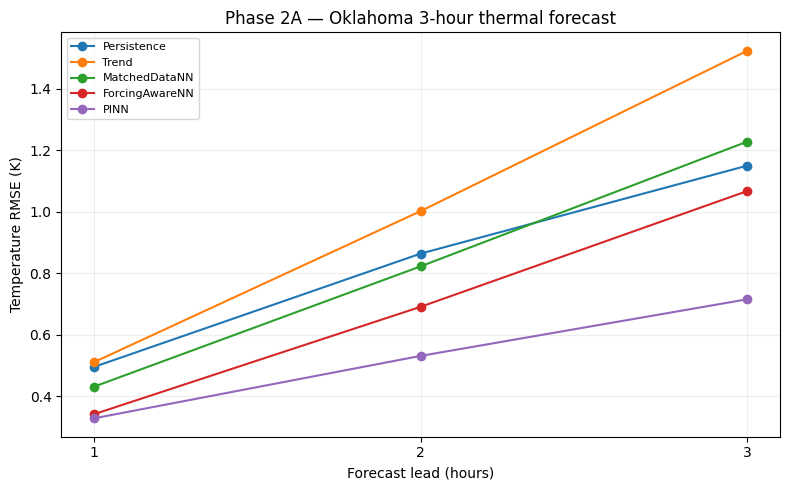

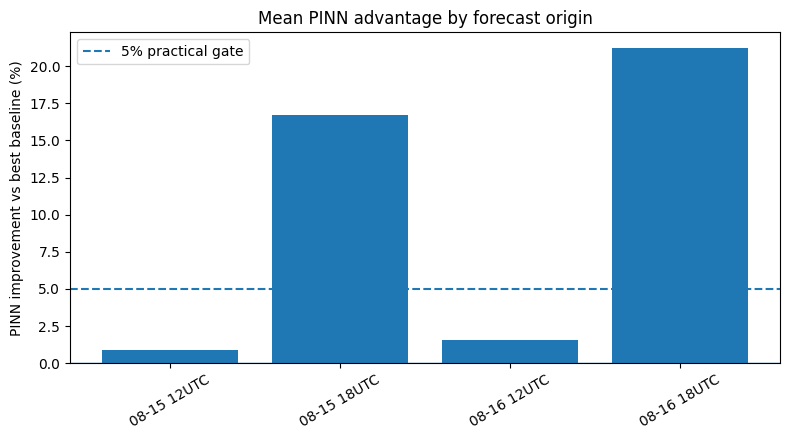

In [21]:

plot_df = results.groupby("Lead_h")[
    [
        "Persistence_RMSE_K",
        "Trend_RMSE_K",
        "MatchedDataNN_RMSE_K",
        "ForcingAwareNN_RMSE_K",
        "PINN_RMSE_K",
    ]
].mean()

fig, ax = plt.subplots(figsize=(8,5))
for col in plot_df.columns:
    ax.plot(
        plot_df.index,
        plot_df[col],
        marker="o",
        label=col.replace("_RMSE_K",""),
    )
ax.set_xlabel("Forecast lead (hours)")
ax.set_ylabel("Temperature RMSE (K)")
ax.set_title("Phase 2A — Oklahoma 3-hour thermal forecast")
ax.set_xticks(range(1,FORECAST_HOURS+1))
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

origin_gain = results.groupby("Origin")["PINN_Improvement_vs_Best_pct"].mean()

fig, ax = plt.subplots(figsize=(8,4.5))
ax.bar(np.arange(len(origin_gain)), origin_gain.values)
ax.axhline(MIN_MEAN_IMPROVEMENT_PCT, linestyle="--", label="5% practical gate")
ax.axhline(0.0, linewidth=1)
ax.set_xticks(np.arange(len(origin_gain)))
ax.set_xticklabels(
    [pd.Timestamp(x).strftime("%m-%d %HUTC") for x in origin_gain.index],
    rotation=30,
)
ax.set_ylabel("PINN improvement vs best baseline (%)")
ax.set_title("Mean PINN advantage by forecast origin")
ax.legend()
plt.tight_layout()
plt.show()



## Interpretation rules

A PINN is **not** called successful merely because its absolute RMSE is small, it beats persistence, one seed wins, or its PDE residual is small.

### If Phase 2A passes
1. freeze this notebook and its settings;
2. replicate on a fresh chronological event not used for development;
3. then move to Phase 2B and deliberately reduce available temperature observations.

### If Phase 2A fails
Inspect:
- exact initial-field check;
- buffer check;
- closure coefficients and whether they hit bounds;
- future physics residual;
- lead-time error growth;
- forcing-aware versus coordinate-only neural baseline.

Only a verified implementation or physics defect justifies another repair. A scientifically valid negative result does not justify arbitrary region/architecture searching.

### v1 → v2 → v3 change log
- removed the auxiliary initial-condition neural network and its arbitrary 0.08 K gate;
- replaced it with a frozen differentiable bilinear ERA5 initial field that is exact at valid grid nodes;
- changed physics collocation from only 700/850/925 hPa to continuous pressure sampling over 700–925 hPa;
- all future-temperature leakage guards, causal stages, baselines, forecast origins, seeds, and final success criteria are unchanged.

- **v3:** restored the missing `make_mlp(...)` helper that v2 still depended on;
- **v3:** added an explicit `display` import;
- **v3:** downstream model construction/training/evaluation path was executed on a reduced synthetic dataset before release.
